## **Sección 3**: Comparación Experimental en 2D

In [85]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from modules_eduardero import *
from auxiliar_eduardito import *

Una vez calibrados los hiperparámetros de *Simulated Annealing* y *Tabu Search* mediante los experimentos en la función unidimensional de Schwefel, se procede a la evaluación comparativa rigurosa de ambos algoritmos en el problema bidimensional de mayor complejidad: la función $f_2(x,y)$. Esta sección constituye el núcleo del trabajo práctico, donde se contrastan experimentalmente las filosofías de búsqueda fundamentalmente diferentes de SA (aceptación probabilística) y TS (memoria explícita). La comparación se realiza bajo condiciones estrictamente controladas con *presupuesto computacional* fijo, permitiendo establecer conclusiones objetivas sobre las fortalezas y debilidades de cada aproximación.

### 3.1 Diseño experimental

El diseño experimental debe garantizar una comparación justa y reproducible entre los dos algoritmos, controlando cuidadosamente todos los factores que podrían introducir sesgos. El concepto central es el **presupuesto computacional fijo**: todos los algoritmos tienen permitido realizar el mismo número de evaluaciones de la función objetivo, independientemente de sus mecanismos internos de operación.


**Presupuesto computacional**:

$$N_{\text{eval}} = 5000 \text{ evaluaciones de } f_2$$

Este presupuesto es idéntico para los dos algoritmos, pero se implementa de manera diferente según las características de cada uno:

**Simulated Annealing**:
- Cada iteración evalúa exactamente 1 vecino generado aleatoriamente
- Número de iteraciones: $N_{\text{max}} = 5000$
- Evaluaciones totales: $5000 \times 1 = 5000$ ✓

**Tabu Search**:
- Cada iteración evalúa $|N|$ vecinos (explora el vecindario)
- Para lograr 5000 evaluaciones totales: $N_{\text{max}} = \lfloor 5000 / |N| \rfloor$
- Por ejemplo, si $|N| = 20$: $N_{\text{max}} = 250$ iteraciones
- Evaluaciones totales: $250 \times 20 = 5000$ ✓

**Protocolo de repeticiones**:

Para garantizar significancia estadística y capturar la variabilidad inherente de los algoritmos estocásticos, se realizan:

$$\text{30 repeticiones independientes por algoritmo}$$

Este número de repeticiones ($n=30$) es suficiente para que el Teorema Central del Límite garantice aproximadamente normalidad de las estadísticas muestrales, permitiendo el cálculo confiable de intervalos de confianza. Cada repetición utiliza una semilla aleatoria diferente pero reproducible (ej: semillas 1-30 para todos los métodos), asegurando reproducibilidad de los experimentos.

**Inicialización y parámetros comunes**:

- **Inicialización**: Todas las repeticiones de todos los algoritmos inician con soluciones aleatorias uniformes en $[-100, 100]$, usando semillas diferentes pero controladas para cada repetición.

- **Operador de vecindario** (SA y TS): Perturbación Gaussiana bidimensional con desviación estándar $\sigma = 10.0$:
  $$x' = x + \mathcal{N}(0, 100), \quad y' = y + \mathcal{N}(0, 100)$$
  Si el candidato sale del dominio, se proyecta al borde más cercano.


**Configuraciones específicas de cada algoritmo**:

**Simulated Annealing**:
$$
\begin{aligned}
T_0 &= [T_{0,\text{óptimo}} \text{ identificado en Sección 1.4}] \\
\alpha &= [\alpha_{\text{óptimo}} \text{ identificado en Sección 1.4}] \\
\text{Schedule:} & \quad T(t) = \alpha^t \cdot T_0 \text{ (geométrico)} \\
N_{\text{max}} &= 5000 \text{ iteraciones}
\end{aligned}
$$

**Tabu Search**:
$$
\begin{aligned}
k &= [k_{\text{óptimo}} \text{ identificado en Sección 2.4}] \\
|N| &= [|N|_{\text{óptimo}} \text{ identificado en Sección 2.4}] \\
N_{\text{max}} &= \lfloor 5000 / |N| \rfloor \text{ iteraciones} \\
\text{Aspiración:} & \quad \text{No (implementación simple)} \\
\text{Tenure:} & \quad \text{Fijo durante toda la ejecución}
\end{aligned}
$$



**Métricas registradas** (para cada una de las 30 repeticiones de cada algoritmo):

1. **Mejor fitness alcanzado**: $f_{\text{best}}$ al finalizar las 5000 evaluaciones
2. **Posición de la mejor solución**: $(x_{\text{best}}, y_{\text{best}})$
3. **Distancia euclidiana al óptimo**: $d = \sqrt{x_{\text{best}}^2 + y_{\text{best}}^2}$
4. **Evaluación en que se encontró el mejor**: número de evaluación donde se alcanzó $f_{\text{best}}$ (permite análisis de convergencia)
5. **Secuencia temporal del mejor fitness**: para cada algoritmo, registrar $f_{\text{best}}(t)$ para $t = 1, 100, 200, \ldots, 5000$ para graficar curvas de convergencia promedio



In [ ]:
T0_optimo  = 1000
alfa_optimo = 0.90
sigma_sa   = 10

k_optimo   = 10
n_optimo   = 20
sigma_ts   = 10
eps_optimo = 1.0

N_eval = 5000
N_sa   = N_eval                 
N_ts   = N_eval // n_optimo     

lower_2d = [-100, -100]
upper_2d = [100,  100]
n_repeat = 30

checkpoints = np.arange(100, N_eval + 1, 100)


In [87]:
def best_so_far_sa(hist_fitness, checkpoints):
    """Running min de hist_fitness (1 entrada/eval) muestreado en checkpoints."""
    arr = np.array(hist_fitness)
    return np.array([arr[:t].min() for t in checkpoints])

results_sa = {"best_fit": [], "best_x": [], "best_dist": [],
              "best_eval": [], "conv_curve": [], "times": []}

for _ in range(n_repeat):
    start_point = [np.random.uniform(-100, 100), np.random.uniform(-100, 100)]
    sa = simulated_annealing(
        function=f_2,
        start_point=start_point,
        lower=[-100],
        upper=[100],
        T_0=T0_optimo,
        alfa=alfa_optimo,
        sigma=sigma_sa,
        cold_function=geometric_cooling,
        n_max=N_sa,
        minimize=True
    )
    t0 = time.time()
    best_point, best_fit = sa.run()
    elapsed = time.time() - t0

    results_sa["best_fit"].append(float(np.atleast_1d(best_fit)[0]))
    results_sa["best_x"].append(np.array(best_point).flatten())
    results_sa["best_dist"].append(float(np.linalg.norm(best_point)))
    results_sa["best_eval"].append(sa.t_best)
    results_sa["conv_curve"].append(best_so_far_sa(sa.hist_fitness, checkpoints))
    results_sa["times"].append(elapsed)

print("SA listo. Mejor fitness:", np.min(results_sa["best_fit"]))


SA listo. Mejor fitness: 0.24303027902191687


In [88]:
def best_so_far_ts(hist_fitness, checkpoints, n_vecinos):
    """Running min de hist_fitness (1 entrada/iter) muestreado en checkpoints de evaluaciones."""
    arr = np.array(hist_fitness)
    # eval t → iter completadas = t // n_vecinos (exacto cuando t es múltiplo de n_vecinos)
    return np.array([arr[:max(1, t // n_vecinos)].min() for t in checkpoints])

results_ts = {"best_fit": [], "best_x": [], "best_dist": [],
              "best_eval": [], "conv_curve": [], "times": []}

for _ in range(n_repeat):
    start_point = [np.random.uniform(-100, 100), np.random.uniform(-100, 100)]
    opt = tabu_search(
        function=f_2,
        start_point=start_point,
        lower=lower_2d,
        upper=upper_2d,
        k=k_optimo,
        n_vecinos=n_optimo,
        sigma=sigma_ts,
        epsilon=eps_optimo,
        n_max=N_ts,
        minimize=True
    )
    t0 = time.time()
    best_point, best_fit = opt.run()
    elapsed = time.time() - t0

    results_ts["best_fit"].append(float(np.atleast_1d(best_fit)[0]))
    results_ts["best_x"].append(np.array(best_point).flatten())
    results_ts["best_dist"].append(float(opt.distance_to_optimum))
    results_ts["best_eval"].append(opt.best_iteration * n_optimo)
    results_ts["conv_curve"].append(best_so_far_ts(opt.hist_fitness, checkpoints, n_optimo))
    results_ts["times"].append(elapsed)

print("TS listo. Mejor fitness:", np.min(results_ts["best_fit"]))


TS listo. Mejor fitness: 0.3322025992238524


In [89]:
def best_so_far_random(hist_fitness, checkpoints):
    arr = np.array(hist_fitness)
    return np.array([arr[:t].min() for t in checkpoints])

results_rand = {"best_fit": [], "best_x": [], "best_dist": [],
                "conv_curve": [], "times": []}

for _ in range(n_repeat):
    best_f = np.inf
    best_x = None
    hist   = []
    t0 = time.time()
    for _ in range(N_eval):
        point = np.array([np.random.uniform(-100, 100), np.random.uniform(-100, 100)])
        f = float(f_2(point))
        if f < best_f:
            best_f = f
            best_x = point.copy()
        hist.append(f)
    elapsed = time.time() - t0

    results_rand["best_fit"].append(best_f)
    results_rand["best_x"].append(best_x)
    results_rand["best_dist"].append(float(np.linalg.norm(best_x)))
    results_rand["conv_curve"].append(best_so_far_random(hist, checkpoints))
    results_rand["times"].append(elapsed)

print("Random listo. Mejor fitness:", np.min(results_rand["best_fit"]))


Random listo. Mejor fitness: 0.4960410497817575


In [90]:
def stats_row(fits, label):
    a = np.array(fits)
    mean = a.mean(); std = a.std(ddof=1)
    return {"Algoritmo": label, "Media": round(mean,4), "Mediana": round(np.median(a),4),
            "Mín": round(a.min(),4), "Máx": round(a.max(),4),
            "Std": round(std,4), "CV": round(std/abs(mean),4)}

display(pd.DataFrame([
    stats_row(results_rand["best_fit"], "Random"),
    stats_row(results_sa["best_fit"],   "SA"),
    stats_row(results_ts["best_fit"],   "Tabu Search"),
]).set_index("Algoritmo"))


,Media,Mediana,Mín,Máx,Std,CV
Algoritmo,,,,,,
Random,1.4258,1.4995,0.4960,2.1000,0.3630,0.2546
SA,0.4847,0.4867,0.2430,0.8645,0.1413,0.2916
Tabu Search,0.6301,0.6611,0.3322,0.9328,0.1565,0.2484


### 3.2 Análisis estadístico comparativo

Una vez completadas las ejecuciones experimentales (30 por algoritmo), se procede al análisis para establecer diferencias entre los métodos y comprender sus características de rendimiento. Esta sección guiará el análisis en los pasos secuenciales: estadísticas descriptivas, visualizaciones, tests de significancia, y análisis de convergencia temporal.

#### Paso 1: Estadísticas descriptivas

**Objetivo**: Caracterizar numéricamente el rendimiento de cada algoritmo mediante métricas de tendencia central, dispersión y valores extremos.

**Instrucciones**:

Para cada uno de los algoritmos (Simulated Annealing, Tabu Search), calcular sobre las 30 repeticiones del mejor fitness alcanzado:

1. **Media aritmética**: $\bar{f} = \frac{1}{30}\sum_{i=1}^{30} f_i$

2. **Mediana**: valor central de la distribución ordenada

3. **Valores extremos**: mínimo (mejor caso observado) y máximo (peor caso observado)

4. **Desviación estándar**: $s = \sqrt{\frac{1}{29}\sum_{i=1}^{30}(f_i - \bar{f})^2}$

5. **Coeficiente de variación**: $CV = s/|\bar{f}|$ (medida normalizada de dispersión)



Organizar estos resultados en una **tabla comparativa**:

| Algoritmo | Media | Mediana | Mín | Máx | Std | CV  |
|-----------|-------|---------|-----|-----|-----|-----|
| SA        | ...   | ...     | ... | ... | ... | ... |
| Tabu      | ...   | ...     | ... | ... | ... | ... |


In [91]:
from scipy import stats

def stats_row(fits, label):
    a = np.array(fits)
    mean = a.mean()
    std  = a.std(ddof=1)
    n    = len(a)
    ic   = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))
    return {
        "Algoritmo": label,
        "Media":     round(mean, 4),
        "Mediana":   round(np.median(a), 4),
        "Mín":       round(a.min(), 4),
        "Máx":       round(a.max(), 4),
        "Std":       round(std, 4),
        "CV":        round(std / abs(mean), 4),
        "IC95% inf": round(ic[0], 4),
        "IC95% sup": round(ic[1], 4),
    }

display(pd.DataFrame([
    stats_row(results_rand["best_fit"], "Random"),
    stats_row(results_sa["best_fit"],   "SA"),
    stats_row(results_ts["best_fit"],   "Tabu Search"),
]).set_index("Algoritmo"))


,Media,Mediana,Mín,Máx,Std,CV,IC95% inf,IC95% sup
Algoritmo,,,,,,,,
Random,1.4258,1.4995,0.4960,2.1000,0.3630,0.2546,1.2903,1.5614
SA,0.4847,0.4867,0.2430,0.8645,0.1413,0.2916,0.4319,0.5375
Tabu Search,0.6301,0.6611,0.3322,0.9328,0.1565,0.2484,0.5716,0.6885


**Interpretación requerida**: Basándose en la tabla, analizar:

1. ¿Qué algoritmo tiene el mejor fitness promedio? ¿Y la mejor mediana?
2. ¿Los intervalos de confianza de SA y Tabu se superponen? ¿Qué indica esto?
3. ¿Qué algoritmo es más consistente (menor CV)? ¿Y más variable?
4. ¿Existe algún algoritmo que tenga el mejor caso absoluto (mínimo) pero no el mejor promedio? ¿Qué implica esto?
5. ¿Cómo se relaciona el tiempo de ejecución con la calidad de soluciones?


1. Simmlated annealing, como debe ser.\
2. No hay una diferencia significativa! 
3. El mas consistente es simmulated annealing, y. el menos es tabu search, debido a la cantidad elevada de iteraciones. Con algunas optimizaciones deberia andar mejro (ej, Criterio de aspiracion)
4. Tabu search llega al mejor minimo, creemos debido a las condiciones iniciales, y su naturaleza similar a hill climbing
5. El simmulated annealing es "5 veces mas lento", pero en terminos practicos es insignificante (al menos en este caso).

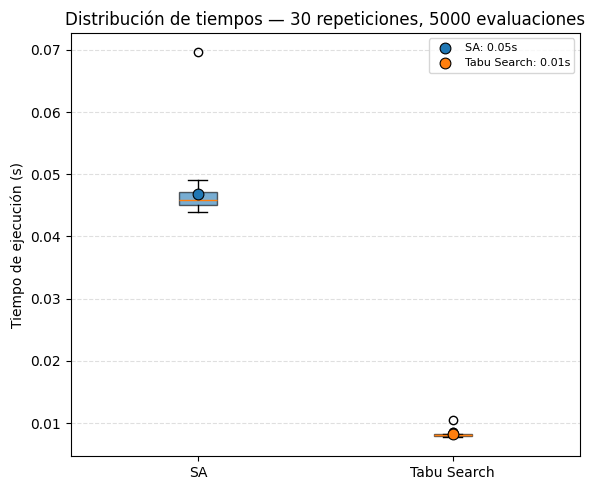

In [92]:
fig, ax = plt.subplots(figsize=(6, 5))

data_times = [results_sa["times"], results_ts["times"]]
labels = ["SA", "Tabu Search"]
colors = ["tab:blue", "tab:orange"]

bp = ax.boxplot(data_times, tick_labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, (times, color) in enumerate(zip(data_times, colors), start=1):
    ax.scatter(i, np.mean(times), color=color, zorder=5, s=60,
               edgecolors="black", linewidths=0.8, label=f"{labels[i-1]}: {np.mean(times):.2f}s")

ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title("Distribución de tiempos — 30 repeticiones, 5000 evaluaciones")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


#### Paso 2: Visualizaciones comparativas

**Objetivo**: Complementar las estadísticas numéricas con representaciones visuales que faciliten la comparación intuitiva de los algoritmos.



**Visualización 2.1: Boxplots del fitness alcanzado**

Generar un gráfico de cajas y bigotes (boxplot) con los tres algoritmos lado a lado, mostrando la distribución completa del mejor fitness alcanzado en las 30 repeticiones. Utilizar colores distintivos para cada algoritmo e incluir outliers.


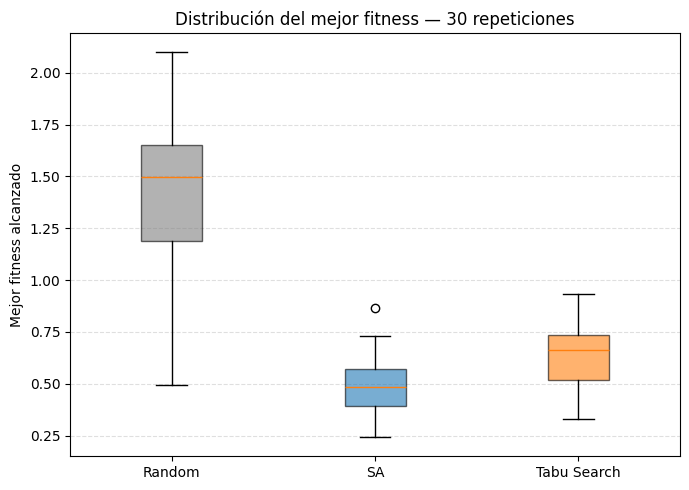

In [93]:
fig, ax = plt.subplots(figsize=(7, 5))

data_fit = [results_rand["best_fit"], results_sa["best_fit"], results_ts["best_fit"]]
labels   = ["Random", "SA", "Tabu Search"]
colors   = ["tab:gray", "tab:blue", "tab:orange"]

bp = ax.boxplot(data_fit, tick_labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Mejor fitness alcanzado")
ax.set_title("Distribución del mejor fitness — 30 repeticiones")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretación requerida**: Observando los boxplots, analizar:

1. ¿Qué algoritmo tiene la mediana más baja (mejor)?
2. ¿Cuál tiene mayor dispersión (rango intercuartil más amplio)?
3. ¿Hay outliers evidentes? ¿En qué algoritmo?
4. ¿Las distribuciones son simétricas o asimétricas?



**Visualización 2.2: Curvas de convergencia**

Generar un gráfico de convergencia mostrando cómo evoluciona el mejor fitness en función del número de evaluaciones para cada algoritmo.

**Especificaciones**:
- Para cada algoritmo, registrar el mejor fitness alcanzado en evaluaciones: 100, 200, ..., 4900, 5000 (50 puntos)
- Calcular la **mediana** del mejor fitness en cada punto (sobre las 30 repeticiones)
- Calcular los **percentiles 25 y 75** en cada punto
- Graficar:
  * Eje X: Número de evaluaciones (0 a 5000)
  * Eje Y: Mejor fitness alcanzado
  * Para cada algoritmo: línea sólida para la mediana, área sombreada entre P25-P75
  * Usar colores distintivos por algoritmo


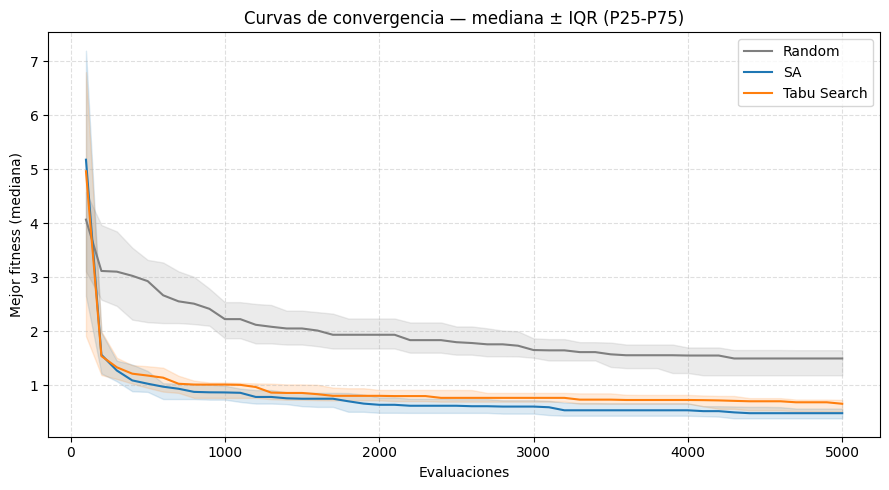

In [94]:
fig, ax = plt.subplots(figsize=(9, 5))

algo_results = [("Random",      results_rand, "tab:gray"),
                ("SA",          results_sa,   "tab:blue"),
                ("Tabu Search", results_ts,   "tab:orange")]

for label, res, color in algo_results:
    curves = np.array(res["conv_curve"])   # (30, 50)
    med  = np.median(curves, axis=0)
    p25  = np.percentile(curves, 25, axis=0)
    p75  = np.percentile(curves, 75, axis=0)
    ax.plot(checkpoints, med, color=color, label=label)
    ax.fill_between(checkpoints, p25, p75, color=color, alpha=0.15)

ax.set_xlabel("Evaluaciones")
ax.set_ylabel("Mejor fitness (mediana)")
ax.set_title("Curvas de convergencia — mediana ± IQR (P25-P75)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Interpretación requerida**: Observando las curvas, analizar:

1. ¿Qué algoritmo converge más rápidamente en las primeras 1000 evaluaciones?
2. ¿Algún algoritmo continúa mejorando significativamente después de 3000 evaluaciones, o todos se estabilizan?
3. ¿Cuál tiene la banda de variabilidad (P25-P75) más estrecha? ¿Qué indica sobre su consistencia?
4. ¿En qué rango de evaluaciones ocurre la mayor diferenciación entre algoritmos?


#### Paso 3: Análisis de métricas complementarias


**Objetivo**: Complementar el análisis de fitness con métricas adicionales que proporcionen perspectivas diferentes sobre el rendimiento.



**Métrica 4.1: Distancia al óptimo global**

Para cada algoritmo, calcular estadísticas de la distancia euclidiana al óptimo $(0,0)$:

$$d_i = \sqrt{x_{\text{best},i}^2 + y_{\text{best},i}^2}, \quad i = 1, \ldots, 30$$



Calcular y reportar:

| Algoritmo | Dist. media | Dist. mediana | Dist. mínima | Dist. máxima |
|-----------|-------------|---------------|--------------|--------------|
| Random    | ...         | ...           | ...          | ...          |
| SA        | ...         | ...           | ...          | ...          |
| Tabu      | ...         | ...           | ...          | ...          |

**Interpretación**: ¿El algoritmo con mejor fitness también tiene menor distancia promedio? ¿O hay discrepancias?


In [95]:
def dist_row(label, dists):
    a = np.array(dists)
    return {"Algoritmo": label, "Dist. media": round(a.mean(), 4),
            "Dist. mediana": round(np.median(a), 4),
            "Dist. mínima": round(a.min(), 4), "Dist. máxima": round(a.max(), 4)}

display(pd.DataFrame([
    dist_row("Random",      results_rand["best_dist"]),
    dist_row("SA",          results_sa["best_dist"]),
    dist_row("Tabu Search", results_ts["best_dist"]),
]).set_index("Algoritmo"))

,Dist. media,Dist. mediana,Dist. mínima,Dist. máxima
Algoritmo,,,,
Random,1.6598,1.4563,0.2401,3.9880
SA,0.1945,0.1566,0.0276,0.7371
Tabu Search,0.3125,0.3371,0.0655,0.7495



**Métrica 4.2: Tasa de éxito ($\varepsilon$-optimalidad)**

Definir una solución como **$\varepsilon$-óptima** si $f(x,y) < \varepsilon$. Para cada $\varepsilon \in \{1.0, 0.5, 0.1\}$, contar cuántas de las 30 repeticiones alcanzaron este nivel.



Reportar en tabla:

| $\varepsilon$ | Random | SA | Tabu |
|:-------------:|:------:|:--:|:----:|
| 1.0           | ... de 30 | ... de 30 | ... de 30 |
| 0.5           | ... de 30 | ... de 30 | ... de 30 |
| 0.1           | ... de 30 | ... de 30 | ... de 30 |


In [96]:
epsilons = [1.0, 0.5, 0.1]
rows = []
for eps in epsilons:
    rows.append({
        "ε": eps,
        "Random":      sum(f < eps for f in results_rand["best_fit"]),
        "SA":          sum(f < eps for f in results_sa["best_fit"]),
        "Tabu Search": sum(f < eps for f in results_ts["best_fit"]),
    })
display(pd.DataFrame(rows).set_index("ε"))

,Random,SA,Tabu Search
ε,,,
1.0,2,30,30
0.5,1,16,6
0.1,0,0,0



**Interpretación requerida**:

1. ¿Qué algoritmo tiene mayor tasa de éxito en encontrar soluciones de alta calidad ($\varepsilon = 0.1$)?
2. ¿Todos los algoritmos logran al menos una solución $\varepsilon < 1.0$, o alguno falla sistemáticamente?
3. ¿Esta métrica de "tasa de éxito" ofrece una perspectiva diferente al fitness promedio? Explicar.

### 3.3 Análisis cualitativo

Más allá de las estadísticas numéricas, el análisis cualitativo proporciona insights sobre los mecanismos subyacentes que explican las diferencias de rendimiento observadas.


#### Distribución espacial de soluciones finales



Generar un **scatter plot en 2D** que muestre la posición final de las 30 mejores soluciones encontradas por cada algoritmo, superpuesto sobre un mapa de calor (heatmap) o contour plot de la función $f_2(x,y)$:

- Eje X: coordenada $x$, Eje Y: coordenada $y$
- Marcar el óptimo global $(0,0)$ con una cruz grande
- Para cada algoritmo, usar un color y forma de marcador distintos (ej: SA = círculos azules, Tabu = triángulos rojos)
- Opcionalmente, incluir círculos concéntricos centrados en el origen para visualizar la distancia radial al óptimo

Esta visualización revela patrones importantes:
- **Concentración espacial**: ¿Las soluciones están agrupadas en regiones específicas o dispersas?
- **Proximidad al óptimo**: ¿Qué algoritmo típicamente encuentra soluciones más cercanas a $(0,0)$?
- **Atrapamiento en óptimos locales**: ¿Hay clusters de soluciones en óptimos locales alejados del origen?



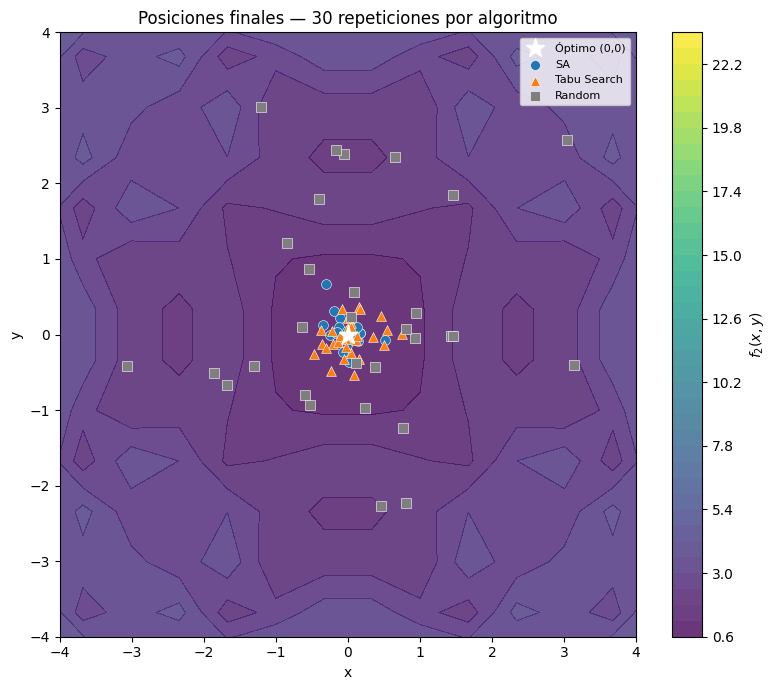

In [100]:
xg = np.linspace(-100, 100, 300)
yg = np.linspace(-100, 100, 300)
X, Y = np.meshgrid(xg, yg)
Z = (X**2 + Y**2)**0.25 * (np.sin(50*(X**2+Y**2)**0.1)**2 + 1)

fig, ax = plt.subplots(figsize=(8, 7))
cp = ax.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.8)
plt.colorbar(cp, ax=ax, label="$f_2(x,y)$")

for r in [10, 25, 50]:
    theta = np.linspace(0, 2*np.pi, 300)
    ax.plot(r*np.cos(theta), r*np.sin(theta), "w--", lw=0.7, alpha=0.5)
ax.plot(0, 0, "w*", markersize=14, label="Óptimo (0,0)", zorder=6)

for label, res, color, marker in [
    ("SA",          results_sa,   "tab:blue",   "o"),
    ("Tabu Search", results_ts,   "tab:orange", "^"),
    ("Random",      results_rand, "tab:gray",   "s"),
]:
    xs = np.array(res["best_x"])
    ax.scatter(xs[:,0], xs[:,1], color=color, marker=marker,
               s=50, edgecolors="white", linewidths=0.4, label=label, zorder=5)

ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Posiciones finales — 30 repeticiones por algoritmo")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

#### Análisis de convergencia por fases



Dividir las 5000 evaluaciones en tres fases: temprana (0-1500), intermedia (1500-3500), y tardía (3500-5000). Para cada fase y cada algoritmo, calcular:

- Proporción de mejoras significativas (mejoras $> 1\%$ sobre el mejor anterior)
- Tasa de mejora promedio en la fase

Esto permite identificar:
- **Exploración temprana**: ¿qué algoritmo encuentra buenas soluciones más rápido inicialmente?
- **Refinamiento tardío**: ¿qué algoritmo continúa mejorando en etapas avanzadas vs estancamiento?



In [98]:
phases = {
    "Temprana (0-1500)":      (0,  15),
    "Intermedia (1500-3500)": (15, 35),
    "Tardía (3500-5000)":     (35, 50),
}

rows = []
for label, res in [("SA", results_sa), ("Tabu Search", results_ts)]:
    curves = np.array(res["conv_curve"])  # (30, 50)
    for phase_name, (i0, i1) in phases.items():
        segment = curves[:, i0:i1]
        start_vals = segment[:, 0:1]
        sig_improvements = np.mean(
            np.any((start_vals - segment) / (np.abs(start_vals) + 1e-12) > 0.01, axis=1)
        )
        mean_rate = np.mean((segment[:, 0] - segment[:, -1]) / (i1 - i0))
        rows.append({
            "Algoritmo": label,
            "Fase": phase_name,
            "% runs con mejora >1%": round(sig_improvements * 100, 1),
            "Tasa mejora promedio": round(mean_rate, 5),
        })

display(pd.DataFrame(rows).set_index(["Algoritmo", "Fase"]))

% runs con mejora >1%  \
Algoritmo   Fase                                            
SA          Temprana (0-1500)                       100.0   
            Intermedia (1500-3500)                   56.7   
            Tardía (3500-5000)                       36.7   
Tabu Search Temprana (0-1500)                       100.0   
            Intermedia (1500-3500)                   33.3   
            Tardía (3500-5000)                       40.0   

                                    Tasa mejora promedio  
Algoritmo   Fase                                          
SA          Temprana (0-1500)                    0.29430  
            Intermedia (1500-3500)               0.00767  
            Tardía (3500-5000)                   0.00468  
Tabu Search Temprana (0-1500)                    0.25190  
            Intermedia (1500-3500)               0.00544  
            Tardía (3500-5000)                   0.00702

#### Tiempo de ejecución vs calidad



Generar un **scatter plot** con:
- Eje X: tiempo promedio de ejecución (segundos)
- Eje Y: fitness promedio alcanzado
- Cada algoritmo como un punto con barras de dispersión (desvío estándar)

Alternativamente, para cada repetición individual, graficar:
- Eje X: tiempo de ejecución de esa repetición
- Eje Y: fitness alcanzado en esa repetición
- 90 puntos totales (30 por algoritmo), código de colores por algoritmo

Esto revela el **trade-off calidad vs tiempo**: un algoritmo puede encontrar mejores soluciones pero requerir más tiempo de cómputo, información relevante para decidir cuál usar en aplicaciones con límites de tiempo estrictos.



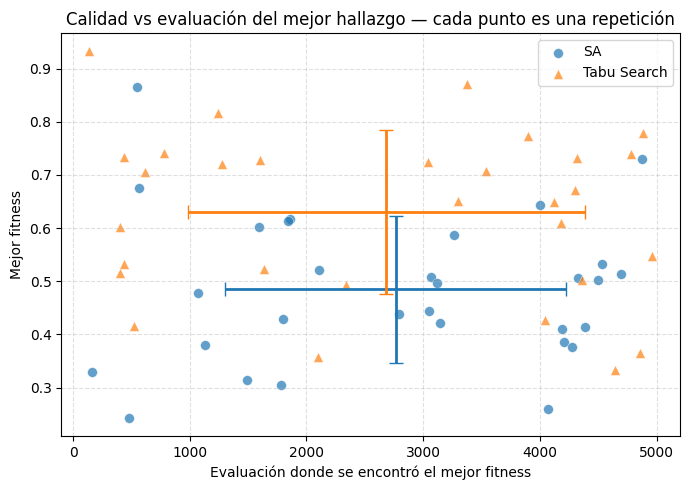

In [99]:
fig, ax = plt.subplots(figsize=(7, 5))

for label, res, color, marker in [
    ("SA",          results_sa, "tab:blue",   "o"),
    ("Tabu Search", results_ts, "tab:orange", "^"),
]:
    evals = np.array(res["best_eval"])
    fits  = np.array(res["best_fit"])
    ax.scatter(evals, fits, color=color, marker=marker, s=50,
               edgecolors="white", linewidths=0.4, alpha=0.7, label=label)
    ax.errorbar(evals.mean(), fits.mean(),
                xerr=evals.std(), yerr=fits.std(),
                color=color, capsize=5, linewidth=2, zorder=5)

ax.set_xlabel("Evaluación donde se encontró el mejor fitness")
ax.set_ylabel("Mejor fitness")
ax.set_title("Calidad vs evaluación del mejor hallazgo — cada punto es una repetición")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### Robustez: coeficiente de variación



El coeficiente de variación $CV = s/|\bar{f}|$ cuantifica la variabilidad relativa de cada algoritmo. Un $CV$ bajo indica que el algoritmo produce resultados consistentes entre repeticiones (robustez), mientras que un $CV$ alto indica alta variabilidad (sensibilidad a inicialización o aleatoriedad interna). Comparar los $CV$ de los tres algoritmos permite evaluar no solo la calidad promedio sino también la confiabilidad.



#### Número de soluciones que alcanzan $\varepsilon$-optimalidad



Definir una solución como $\varepsilon$-óptima si su fitness está dentro de una tolerancia del óptimo global:
$$f(x,y) < \varepsilon, \quad \text{donde } \varepsilon \in \{1.0, 0.5, 0.1\}$$

Para cada algoritmo y cada valor de $\varepsilon$, contar cuántas de las 30 repeticiones alcanzaron una solución $\varepsilon$-óptima. Presentar en una tabla:

| $\varepsilon$ | Random | SA | Tabu |
|:-------------:|:------:|:--:|:----:|
| 1.0           |  ...   | ... | ... |
| 0.5           |  ...   | ... | ... |
| 0.1           |  ...   | ... | ... |

Esto complementa las estadísticas de fitness promedio con una medida de **tasa de éxito absoluta**: no solo importa qué tan bien se desempeña en promedio, sino cuántas veces realmente resuelve el problema satisfactoriamente.


---